In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.5_all_data_extra.tsv", sep="\t")

fold0_05["fold"] = [0 for i in range(len(fold0_05))]
fold0_05["target"] = [-0.5 for i in range(len(fold0_05))]

In [3]:
fold1_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.5_all_data_extra.tsv", sep="\t")

fold1_05["fold"] = [1 for i in range(len(fold1_05))]
fold1_05["target"] = [-0.5 for i in range(len(fold1_05))]

In [4]:
fold2_05 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.5_all_data_extra.tsv", sep="\t")

fold2_05["fold"] = [0 for i in range(len(fold2_05))]
fold2_05["target"] = [-0.5 for i in range(len(fold2_05))]

In [5]:
fold0_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.4_all_data_extra.tsv", sep="\t")

fold0_04["fold"] = [0 for i in range(len(fold0_04))]
fold0_04["target"] = [-0.4 for i in range(len(fold0_04))]

In [6]:
fold1_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.4_all_data_extra.tsv", sep="\t")

fold1_04["fold"] = [1 for i in range(len(fold1_04))]
fold1_04["target"] = [-0.4 for i in range(len(fold1_04))]

In [7]:
fold2_04 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.4_all_data_extra.tsv", sep="\t")

fold2_04["fold"] = [2 for i in range(len(fold2_04))]
fold2_04["target"] = [-0.4 for i in range(len(fold2_04))]

In [8]:
fold0_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold0_-0.3_all_data_extra.tsv", sep="\t")

fold0_03["fold"] = [0 for i in range(len(fold0_03))]
fold0_03["target"] = [-0.3 for i in range(len(fold0_03))]

In [9]:
fold1_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold1_-0.3_all_data_extra.tsv", sep="\t")

fold1_03["fold"] = [1 for i in range(len(fold1_03))]
fold1_03["target"] = [-0.3 for i in range(len(fold1_03))]

In [10]:
fold2_03 = pd.read_csv(f"/scratch1/smaruj/genomic_insertion_loci/fold2_-0.3_all_data_extra.tsv", sep="\t")

fold2_03["fold"] = [2 for i in range(len(fold2_03))]
fold2_03["target"] = [-0.3 for i in range(len(fold2_03))]

In [11]:
df = pd.concat([fold0_05, fold1_05, fold2_05, fold0_04, fold1_04, fold2_04, fold0_03, fold1_03, fold2_03], ignore_index=True)

In [12]:
df.columns

Index(['chrom', 'start_query', 'end_query', 'centered_start', 'centered_end',
       'last_accepted_step_query', 'active_count', 'neutral_count',
       'repressive_count', 'total', 'active_fraction', 'neutral_fraction',
       'repressive_fraction', 'SCD', 'URQ_result', 'URQ_target', 'URQ_init',
       'num_edits', 'GC_seq', 'GC_slice', 'GC_slice_edited', 'init_CTCFs_num',
       'CTCFs_num', 'FIMO_sum', 'FIMO_max', 'orientation', 'fold', 'target'],
      dtype='object')

In [13]:
df["URQ_delta"] = df["URQ_result"] - df["URQ_init"]

In [14]:
df['optimization_successful'] = df['SCD'] > 30

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

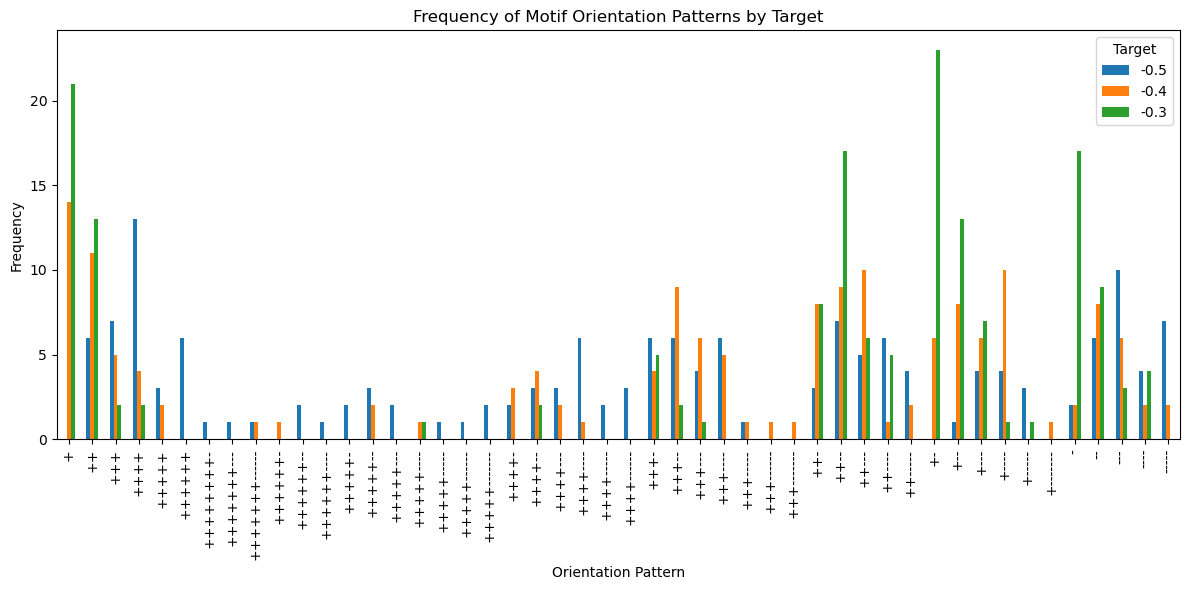

In [16]:
# 1. Filter out entries with orientation "no"
filtered_df = df[df['orientation'] != "no"]

# 2. Count orientation frequencies grouped by target
counts = (
    filtered_df
    .groupby(['orientation', 'target'])
    .size()
    .unstack(fill_value=0)  # rows = orientation, columns = targets
)

# 3. Plot
counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns by Target")
plt.xticks(rotation=90)
plt.legend(title="Target")
plt.tight_layout()
plt.show()

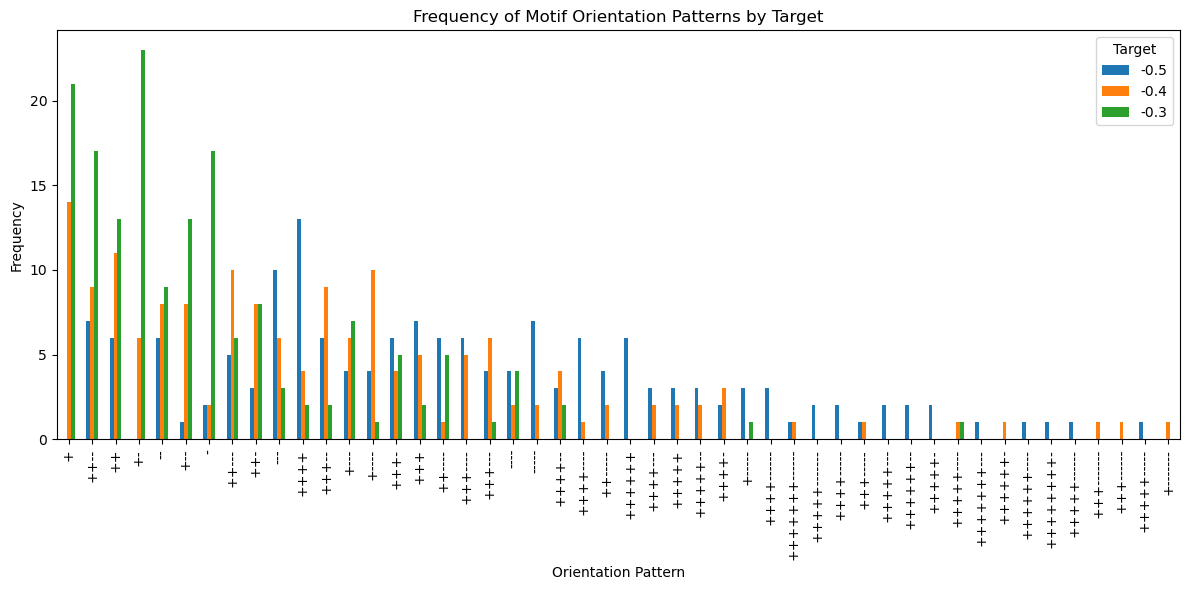

In [17]:
# 1. Filter out rows with 'no' orientation
filtered_df = df[df['orientation'] != "no"]

# 2. Count orientation frequencies grouped by target
counts = (
    filtered_df
    .groupby(['orientation', 'target'])
    .size()
    .unstack(fill_value=0)  # rows = orientation patterns, columns = targets
)

# 3. Sort by total frequency (row sum)
counts = counts.loc[counts.sum(axis=1).sort_values(ascending=False).index]

# 4. Plot
counts.plot(kind='bar', figsize=(12, 6))
plt.xlabel("Orientation Pattern")
plt.ylabel("Frequency")
plt.title("Frequency of Motif Orientation Patterns by Target")
plt.xticks(rotation=90)
plt.legend(title="Target")
plt.tight_layout()
plt.show()

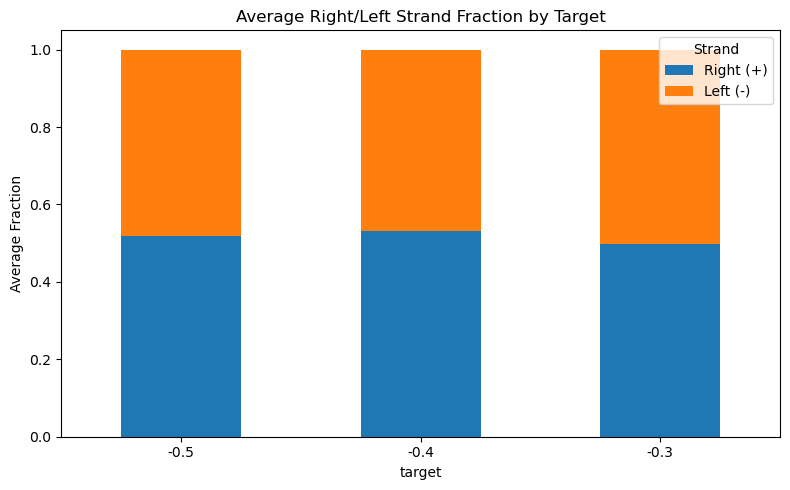

In [19]:
# 1. Filter out "no" orientations
filtered_df = df[df['orientation'] != "no"].copy()

# 2. Compute right and left fractions
def compute_fraction(orient, symbol):
    return orient.count(symbol) / len(orient)

filtered_df['right_fraction'] = filtered_df['orientation'].apply(lambda x: compute_fraction(x, '+'))
filtered_df['left_fraction'] = filtered_df['orientation'].apply(lambda x: compute_fraction(x, '-'))

# 3. Group by target and compute average fractions
fractions_by_target = (
    filtered_df
    .groupby('target')[['right_fraction', 'left_fraction']]
    .mean()
)

# 4. Plot stacked bar chart
fractions_by_target.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#1f77b4', '#ff7f0e'])
plt.ylabel("Average Fraction")
plt.title("Average Right/Left Strand Fraction by Target")
plt.legend(["Right (+)", "Left (-)"], title="Strand")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

